# Individuell uppgift - Hälsostudie

---

## Introduktion

Jag, en fiktiv dataanalytiker på ett forskningsinstitut, Fejk Forskning<sup>™</sup>, har fått i uppdrag att analysera data från en hälsostudie som institutet har bedrivit. 

Studien har sammanställt 800 deltagares ålder, kön, vikt, längd, blodtryck, kolesterolnivå, rökvanor och om de har en viss sjukdom. 

Mitt uppdrag är att undersöka relationen mellan blodtryck och rökning. 

Uppgiften är indelad i två delar: Del 1 Grundläggande analys och statistik och Del 2 Fördjupning och pipeline. 

Allt arbete presenteras i den här rapporten.

---







## Dataförberedelse och "Rengöring"

In [1]:
"""Importera paket"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sc

"""Importera data"""

df = pd.read_csv("data/health_study_dataset.csv")

Det första jag gör att att importera de paket jag vet kommer behövas i det här arbetet. 
Jag väljer att ge paketen kortare namn för att de ska vara smidigare att använda. 

csv-filen läses in som en DataFrame i variabeln df. 

### Få en första överblick av datasetet

In [2]:
"""Kolla kolumner och struktur"""

df.head()

,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease
0,1,57,F,168.9,65.8,141.8,4.58,No,0
1,2,47,M,180.4,95.9,144.8,5.18,Yes,0
2,3,59,F,169.9,82.2,151.7,6.16,No,0
3,4,72,M,157.7,93.1,151.0,6.63,No,0
4,5,46,M,192.6,104.1,144.1,5.21,No,0


In [3]:
"""Kolla Dtype"""

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           800 non-null    int64  
 1   age          800 non-null    int64  
 2   sex          800 non-null    object 
 3   height       800 non-null    float64
 4   weight       800 non-null    float64
 5   systolic_bp  800 non-null    float64
 6   cholesterol  800 non-null    float64
 7   smoker       800 non-null    object 
 8   disease      800 non-null    int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 56.4+ KB


In [4]:
"""Kolla antalet NaN i varje kolumn"""

df.isna().sum()

id             0
age            0
sex            0
height         0
weight         0
systolic_bp    0
cholesterol    0
smoker         0
disease        0
dtype: int64

In [5]:
"""Kolla antalet dubletter"""

print(f"Antal dubletter: {df.duplicated().sum()}")

Antal dubletter: 0


För att få grepp om hur komplett - eller icke-komplett - datan är anväder jag mig av följande funktioner: 

* .head()
* .info()
* .isna()
* .duplicated()

Jag konstaterar att det inte saknas några värden och att det heller inte finns några dubletter. 

Den enda anmärkningen jag har är att kolumnerna "smoker" och "sex" har fel Dtype. 

Kolumnerna är skapade med Dtype "object" vilket strängar ofta blir, men enligt pandas dokumentationen är det bättre att använda Dtype "category" när: 

* Det är strängar med bara några få värden. Som i det här fallet: F eller M och Yes eller No 
* Man ska använda datan i analys eller när man ska visuallisera den

Källa: https://pandas.pydata.org/pandas-docs/stable/user_guide/categorical.html

Jag väljer därför att ändra från "object" till "category". Se nedan: 


### Ändra Dtypes

In [6]:
"""Ändra från object till category för kolumnerna sex och disease"""

df["smoker"] = df["smoker"].astype("category")
df["sex"] = df["sex"].astype("category")

---

## Beskrivande analys

### Sammanställning av nyckeltal

In [7]:
"""
Beräkning av min, max, medel och median
för age, height, weight, systolic_bp och cholesterol
"""

stats = (
    df[["age", "height", "weight", "systolic_bp", "cholesterol"]]
    .describe()
    .round(1)
    .loc[["min", "max", "mean", "50%"]]
    .rename(index={"50%": "median"})
)
print(stats)

         age  height  weight  systolic_bp  cholesterol
min     18.0   144.4    33.7        106.8          2.5
max     90.0   200.4   114.4        185.9          7.9
mean    49.4   171.8    73.4        149.2          4.9
median  50.0   171.4    73.2        149.4          5.0


Jag väljer att använda funktionen .describe() på min DataFrame för att snabbt och lätt räkna ut min, max, medel och median. 

.describe() utan "filter" visar alla kolumner som finns med i df:en, men jag ville bara ha med vissa av kolumnerna. 

M.h.a. inre brackets gör man först en lista över de kolumner som ska vara med. Sen plockas datan ut från df:en m.h.a. de yttre klamrarna. 

(https://pandas.pydata.org/docs/getting_started/intro_tutorials/03_subset_data.html)

.describe() ger också ett antal rader till som inte var relevanta för den här presentationen. Att välja ut de rader (eller index) som ska vara med fungerar typ som på samma sätt som med att välja ut kolumner.

Men man måste specificera att det är "x-axeln" i DataFram:en och inte "y-axeln". Detta görs med .loc. 

(https://pandas.pydata.org/docs/user_guide/indexing.html) 

Namnet på raden/index för median som kommer automatisk med funktionen .describe() är "50%", men det är lite svårt att förstå tycker jag så jag valde att ändra namnet till "median". 

Detta gjorde jag med funktionen .rename() som byter namn på etiketter i en DataFrame. Med "index" specificerar man att det är en radetikett som ska ändras. 

(Motsvarande för en kolumn hade varit "columns")

(https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rename.html)

Och sist men inte minst så valde jag att avrunda alla värden till en decimal med .round(1). 

Jag valde en decimal för att ursprungsdatan inte är mer precis än så. 

### Explorativ Dataanalys (EDA)

För att få en känsla för hur datan är fördelad så skapar jag ett antal diagram: 

* Histogram över studiedeltagarnas ålder
* Histogram över studiedeltagarnas blodtryck
* Boxplot som visar blodtrycket hos kvinnor och män i studien
* Stapeldiagram över andelen kvinnor och män i studien
* Stapeldiagram över andelen deltagare med sjukdom
* Stapeldiagram över andelen deltagare som röker 
* Spridningsdiagram över blodtryck och ålder 

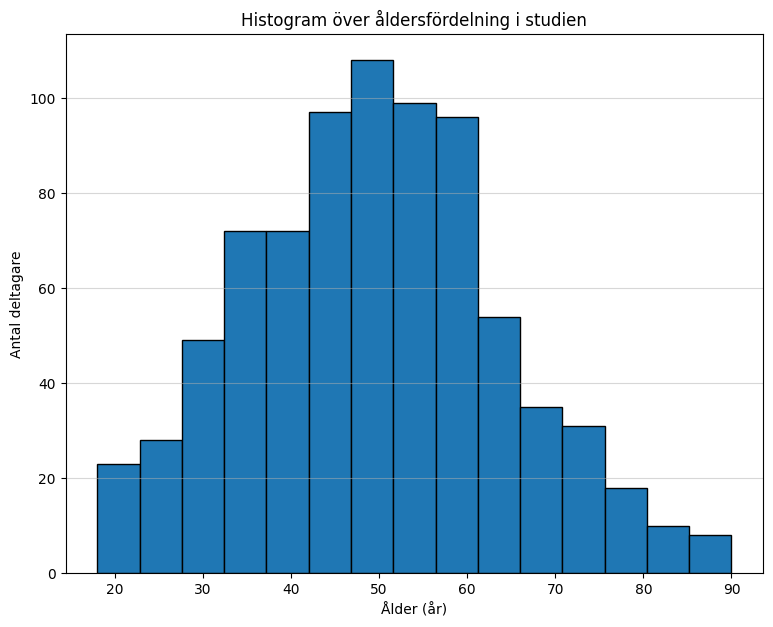

In [8]:
"""Skapar histogram över deltagarnas ålder"""

fig, ax = plt.subplots(figsize=(9, 7))
ax.hist(df["age"], bins=15, edgecolor="black")
ax.set_title("Histogram över åldersfördelning i studien")
ax.set_xlabel("Ålder (år)")
ax.set_ylabel("Antal deltagare")
ax.grid(axis="y", alpha=0.5)

Diagrammet visar en någorlunda normalfördelning kring medelvärdet (50 år).

---

Att välja antalet bins är svårt. Även om det finns riktlinjer och formler för att räkna ut "korrekt" antal bins, är det ändå så att man i slutändan får utgå ifrån sin egen data och pröva sig fram. 

I vissa fall kan det vara aktuellt att ha olika stora bins, men vanligtvis använder man sig av bins som är lika stora. 

En mycket vanligt använd formel för att räkna ut antal bins är Square-root choice. Där antalet bins, k = roten ur antalet datapunkter. 

I mitt fall skulle k bli 28, men det tyckte jag fick histogrammet att se för rörigt ut. 

(Källa: https://en.wikipedia.org/wiki/Histogram)

Ålderspannet i studiens dataset är ungefär 70 år (90 - 18) och med 15 bins blir det ungefär 2 bins per 10 årspann. 

Det kändes lagom. 


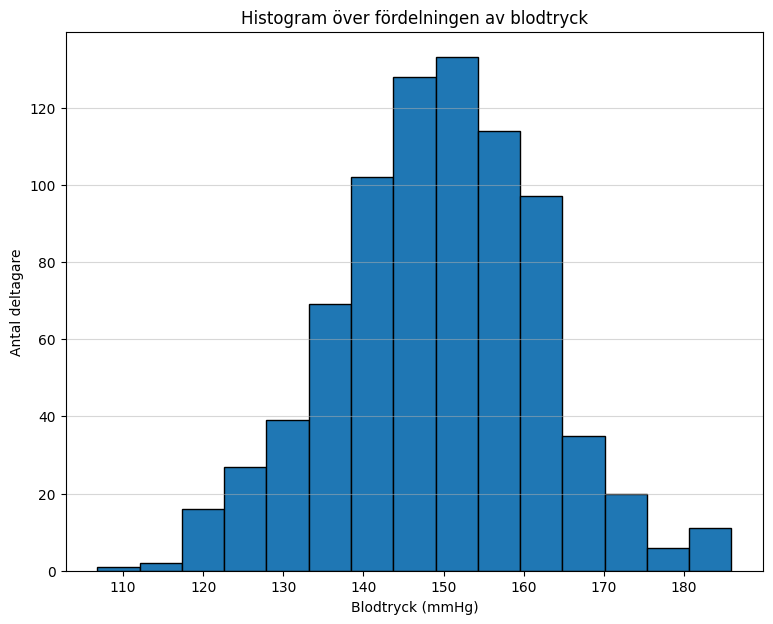

In [9]:
"""Skapar histogram över deltagarnas blodtryck"""

fig, ax = plt.subplots(figsize=(9, 7))
ax.hist(df["systolic_bp"], bins=15, edgecolor="black")
ax.set_title("Histogram över fördelningen av blodtryck")
ax.set_xlabel("Blodtryck (mmHg)")
ax.set_ylabel("Antal deltagare")
ax.grid(axis="y", alpha=0.5)

Diagrammet visar en någorlunda normalfördelning kring 145-155 mmHg.


---

Även här kändes 15 bins lagom.

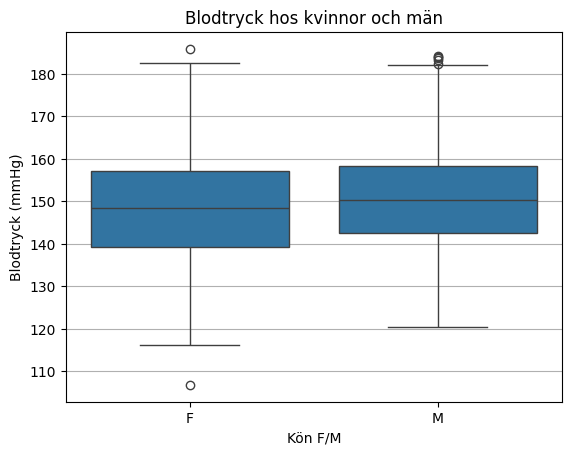

In [10]:
"""Boxplot, Blodtryck: kvinnor vs män"""

ax = sns.boxplot(df, x="sex", y="systolic_bp")
ax.set(
    xlabel= "Kön F/M",
    ylabel= "Blodtryck (mmHg)",
    title= "Blodtryck hos kvinnor och män"
)
ax.grid(True, axis="y")
plt.show()

Diagrammet visar att: 

* spridningen är större bland kvinnorna i studien. Detta syns dels i att interkvartilavståndet är bredare för kvinnor och dels att hela intervallet täcker ett något större område
* män i genomsnitt har något högre blodtryck 
* hos kvinnorna finns det outliers i båda ändarna, medan hos männen finns det flertalet outliers i den övre änden

---


matplotlib.pyplot.boxplot tar ett argument som är en array eller en sekvens av arrayer. 

Men det jag ville plotta var två kolumner ur en DataFrame, där den ena kolumnen dessutom skulle delas upp i "F" och "M". 

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html

Att omvandla mitt format till det matplotlib "vill ha" kändes krånligt så jag började kolla efter ett enklare sätt. 

Jag sprang på den här online-guiden:

https://www.geeksforgeeks.org/python/how-to-create-boxplots-by-group-in-matplotlib/ 

Och upptäckte att seaborn gör det jag ville hur enkelt som helst. Med seaborn var det bara att ange vad som skulle vara på x-axeln och vad som skulle vara på y-axeln. 

I seaborn:s dokumentation finns det ett faq-avsnitt där jag hittade svar på hur man skriver titles och hur man får bort tråkig/onödig text som kom med (plt.show() löste det). 

Allt detta fungerade på samma sätt som med matplotlib så jag testade att lägga till grid på "det gamla sättet" och det fungerade ju! 

https://seaborn.pydata.org/faq.html 

Seaborn är ett bibliotek som används för att skapa statistiska diagram. Det bygger på Matplotlib och fungerar bra tillsammans med Pandas. 

Biblioteket gör det enklare att utforska och förstå data, då det automatiskt hanterar gruppering, färgkodning och beräkningar.

https://seaborn.pydata.org/tutorial/introduction.html

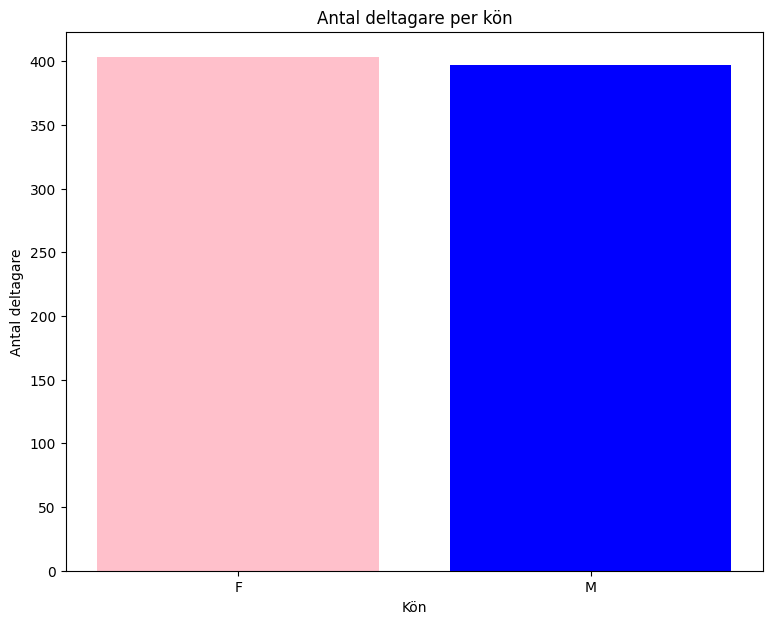

In [11]:
"""Stapeldiagram över antalet kvinnor och män"""

num_women_men = df["sex"].value_counts()

fig, ax = plt.subplots(figsize=(9, 7))
ax.bar(num_women_men.index, num_women_men.values, color=["pink", "blue"])
ax.set(
    title = "Antal deltagare per kön",
    xlabel = "Kön",
    ylabel = "Antal deltagare",
)
plt.show()

Historiskt har inte kvinnors hälsa studerats i samma utsträkning som mäns. Därför var det viktigt för mig att kolla hur fördelningen såg ut i den här studien. 

\#genderequality

\#women-supporting-women

\#womensempowerment


---

matplotlib.pyplot.bar tar två argument: x och height (y)

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html

I mitt fall skulle x vara F eller M från kolumnen "sex" 

Och y skulle vara motsvarande antal. 

Att räkna antalet i en kolumn görs enkelt med .value_counts() och detta ger en Panda Series som ser ut så här:

```
Sex     Count
F       403
M       397
```

Jag sparade detta i en ny variabel, num_women_men, för att den skulle gå att använda.

https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html

.index hämtar etiketterna ur num_women_men.

https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.index.html

På liknande sätt hämtas värdena ur num_women_men h.j.a. .values. 

https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.values.html

Dessa två delar blir mina x- och y-argument när jag sen plottar diagrammet. 

Jag gör på samma sätt med stapeldiagrammen över andelen med sjukdom och andelen rökare.

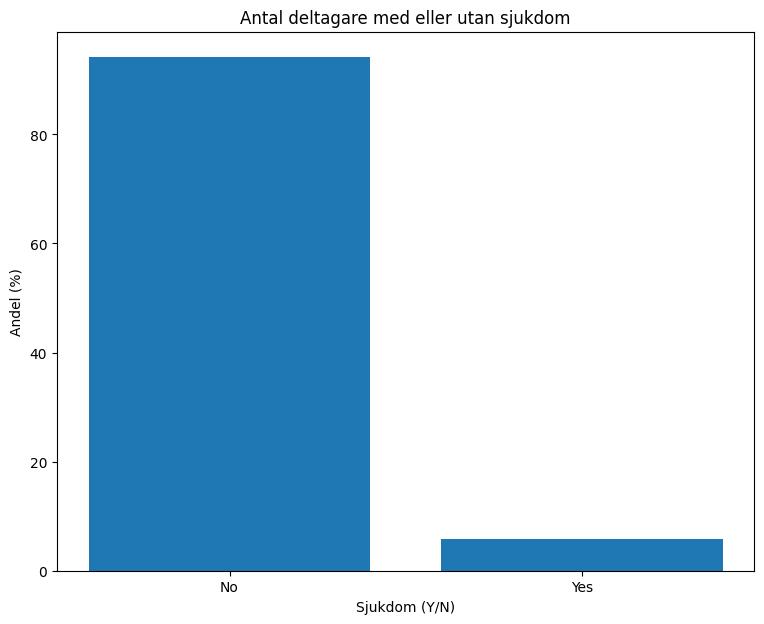

In [12]:
"""Stapeldiagram över andelen med sjukdom"""

num_disease = df["disease"].value_counts(normalize=True).round(4).rename(index={0: "No", 1: "Yes"}) * 100

fig, ax = plt.subplots(figsize=(9, 7))
ax.bar(num_disease.index, num_disease.values)
ax.set(
    title = "Antal deltagare med eller utan sjukdom",
    xlabel = "Sjukdom (Y/N)",
    ylabel = "Andel (%)",
)
plt.show()

De allra flesta deltagare är inte sjuka.

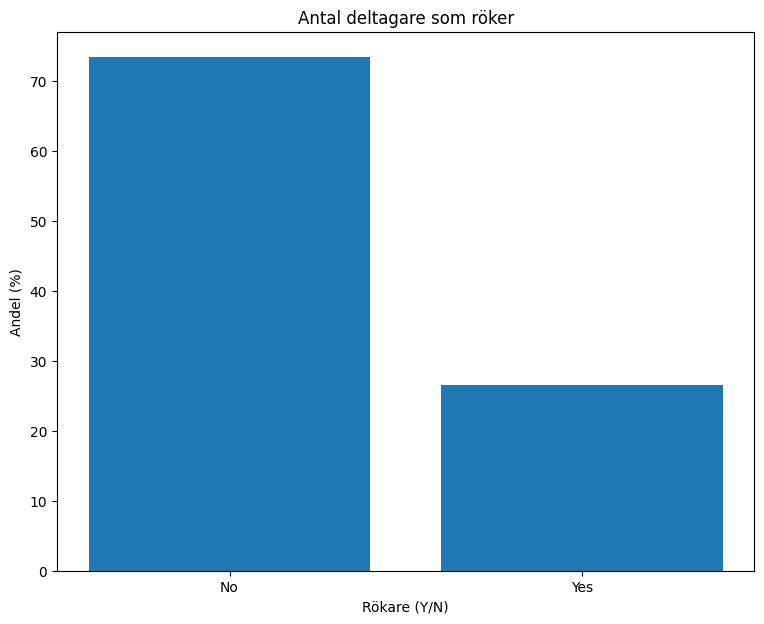

In [13]:
"""Stapeldiagram över andelen rökare"""

num_smoker = df["smoker"].value_counts(normalize=True).round(4) * 100

fig, ax = plt.subplots(figsize=(9, 7))
ax.bar(num_smoker.index, num_smoker.values)
ax.set(
    title = "Antal deltagare som röker",
    xlabel = "Rökare (Y/N)",
    ylabel = "Andel (%)",
)
plt.show()

Lite mer än en fjärdedel av deltagarna röker.

---


pandas.Series.value_counts har lite olika parametrar, däribland "normalize".

Om det inte är specificerat så är normalize=False, vilket ger antal. 

Men normalzie=True ger andelar (proportioner), vilket kändes som mer rimligt än det faktiska antalet. 

https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html

I kolumnen "disease" är datan 1 eller 0, inte Yes eller No, vilket gav ett knasigt resultat. 

Men då fick jag användning av .rename(index=) igen för att ändra 1 till Yes och 0 till No. 

Sedan visade det sig också att det är så lätt som att bara multiplicera allt med 100 för att få procent :) 

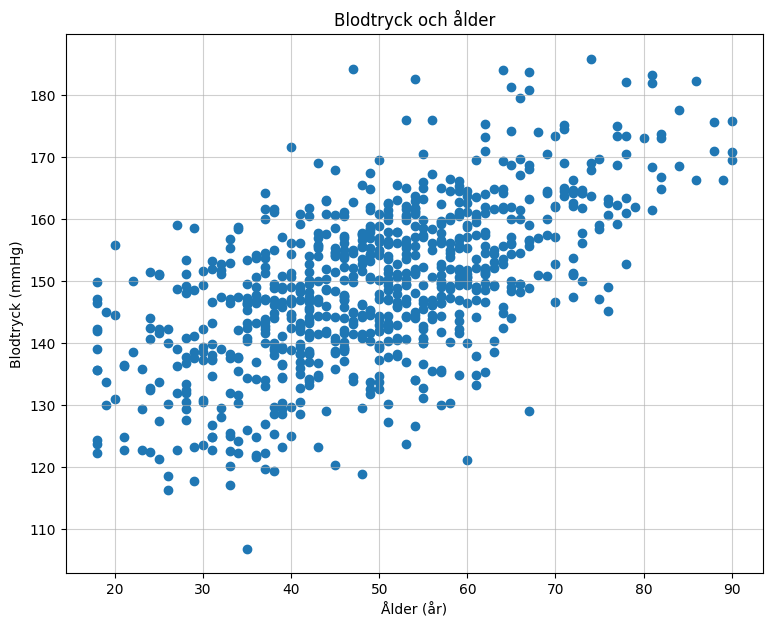

In [14]:
"""Scatterplot, blodtryck vs ålder"""

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(df["age"], df["systolic_bp"])
ax.set(
    title = "Blodtryck och ålder",
    xlabel = "Ålder (år)",
    ylabel = "Blodtryck (mmHg)",
)
ax.grid(True, alpha=0.6)
plt.show()

Varje punkt representerar en individ i studien. 

Spridningsmönstret visar på ett positivt samband. 

Några punkter ligger utanför mönstret och kan betraktas som outliers. 

https://www.statology.org/which-variable-x-axis-y-axis/

---


## Simulering kopplad till caset

I detta avsnitt slumpar jag fram 1000 personer med samma risk för sjukdom som för deltagarna i studien. 

Detta gör jag med en simulering och syftet är att visa på stickprovsvariation. 

Mitt dataset är bara ett stickprov av många möjliga stickprov och på grund av slumpen kommer medelvärdet, eller andelen sjuka, variera mellan olika stickprov. 

In [15]:
"""Beräkna andelen sjuka och andelen friska"""

disease_yes = df["disease"].mean()
disease_no = 1.0 - disease_yes

Jag har ju redan räknat ut andelen sjuka och friska i studien lite längre upp m.h.a value_counts()

Men det ger mig inte två klockrena variabler att använda som det här sättet ovan. 

Eftersom datan i kolumnen "disease" är 1:or och 0:or med Dtype int så går det att addera ihop alla dessa siffror och räkna medelvärdet.

Men det är ju bara 1:orna som "kommer bidra med något". Därför blir medelvärdet samma som andelen sjuka. 

Sedan blir andelen som inte har sjukdomen bara 1 - "andelen sjuka"

In [16]:
"""Slumpa fram 1000 personer med samma sannolikhet för sjukdom"""

np.random.seed(42)

sim = np.random.choice([0, 1], size=1000, replace=True, p=[disease_no, disease_yes])
sim_mean = sim.mean()

print(f"Den simulerade andelen med sjukdom är: {sim_mean}")
print(f"Den verkliga andelen (i stickprovet) är: {disease_yes}")
print(f"Skillnaden mellan de båda resultaten är: {disease_yes - sim_mean:.5f}")

Den simulerade andelen med sjukdom är: 0.056
Den verkliga andelen (i stickprovet) är: 0.05875
Skillnaden mellan de båda resultaten är: 0.00275


Mycket riktigt ser vi att det slumpade stickprovets medelvärde skiljer sig åt från medelvärdet på mitt dataset. 

Men det här är ju bara *en* simulering, vad hade ytterligare en simulering gett för resultat? 

Vad hade 10 simulering gett för resultat? 1000? 

Och hur mycket hade dessa resultat, i snitt, skiljt sig åt från medelvärdet på mitt stickprov, mitt dataset? 

Exempel på detta ser vi i nästa avsnitt, Konfidensintervall. 

---
Numpy har en funktion som genererar ett slumpmässigt urval. Funktionen är numpy.random.choice. 

Funktionen kan ta en array som argument, i mitt fall en lista med 0 eller 1. 

Om det är en array man har "stoppat in" i funktionen så kan man med p= bestämma hur stor sannolikheten ska vara att det blir 0 eller 1. 

Sannolikheten att det ska bli 0 är disease_no och sannolikheten att det ska bli 1 är disease_yes. 

Därför måste disease_no och disease_yes skrivas i samma ordning som 0 och 1, annars får man inte det resultat man vill ha. 

size=1000 bestämmer hur stor output man får. 

replace=True är default, men jag valde att ha med det för att koden blir tydligare då. 

replace=True säger att "när man har dragit en kula ur påsen så läggs den tillbaka". Samma kula kan alltså bli dragen flera gånger om. 

https://numpy.org/doc/2.3/reference/random/generated/numpy.random.choice.html#numpy-random-choice

---

## Beräkning av konfidensintervall

Ett konfidensintervall kvantifierar osäkerheten i en statistisk mätning. 

En statistisk mätning kan sällan göras på en hel population, utan görs på stickprov. 

Som vi såg i avsittet innan så gav ett nytt, slumpmässigt stickprov ett annat medelvärde jämfört med medelvärdet på deltagarna i studien. 

Hur säkra, eller osäkra, bör vi då vara på vårt eget resultat? 

Det är den osäkerheten som konfidensintervallet visar. Ett smalt intervall är säkert, ett brett intervall är osäkert. 

Vanligtvis använder man sig av ett 95%-igt konfidensintervall. 

En statistisk mätning vill hitta det "sanna" medelvärdet och vad det 95%-iga konfidensintervallet säger är att:

"Vi är 95% säkra på att det intervall vi har beräknat omfattar det sanna medelvärdet." 

Och om intervallet är brett så blir ju resultatet mindre användbart. 

<br><br>

Det finns olika sätt att beräkna konfidensintervall på. I den har rapporten använder jag mig av: 

* Normalapproximation
* Bootstrap 

för att beräkna konfidensintervallet för medelvärdet av blodtrycket.

Båda bygger på det stickprov man har. Rent teoretiskt skulle det här stickprovet vara helt åt skogen annorlunda jämfört med alla andra möjliga stickprov. 

Men då urvalet är stort (800) (vilket ofta innebär att medelvärdet stabiliseras och variationen minskar) och vi tidigare i rapporten såg att blodtrycket var ungefär normalfördelat

så utgår jag ifrån att stickprovet inte är *helt åt skogen annorlunda*.

Vi får se vad beräkningarna visar:

https://www.youtube.com/watch?v=TqOeMYtOc1w

https://www.youtube.com/watch?v=xjYEYBvPaSc&list=PLXkHB_gtvM_UqA_oVsyieSL-a1TYRUeYC&index=32&t=4s

### Normalapproximation

In [17]:
"""Beräkna 95% konfidensintervall med normalapproximation"""

systolic_bp_mean = df["systolic_bp"].mean()
systolic_bp_std = df["systolic_bp"].std()
systolic_bp_num = df["systolic_bp"].count()
se = systolic_bp_std / (np.sqrt(systolic_bp_num))
ci_min_normal = systolic_bp_mean - (1.96 * se)
ci_max_normal = systolic_bp_mean + (1.96 * se)

print(f"Medelvärdet på deltagarna i studien är: {systolic_bp_mean:.1f}")
print(f"95% konfidensintervall är: {ci_min_normal:.3f} - {ci_max_normal:.3f}")


Medelvärdet på deltagarna i studien är: 149.2
95% konfidensintervall är: 148.292 - 150.065


Normalapproximation beräknas med följande formel:

medelvärde ± (1.96 x standardfel)

Normalapproximation utgår ifrån en standardiserad klockformad kurva. 

På den här kurvan är medelvärdet 0 och standardavvikelsen 1. 

Detta gör att 95% av hela datan hamnar innanför -1.96 och +1.96. 

Därav 1.96 i formeln. 

För att beräkna standardfelet behövs standardavvikelsen, std, och antalet datapunkter, n. 

Detta beräknas snabbt och lätt med std() och count(). 

Formeln för standardfelet, se, är sedan:

se = std / √n

Eller som i min kod:

se = systolic_bp_std / (np.sqrt(systolic_bp_num))

Resultatet blir: 148.292 - 150.065 vilket är ett smalt intervall.

https://www.youtube.com/watch?v=xjYEYBvPaSc&list=PLXkHB_gtvM_UqA_oVsyieSL-a1TYRUeYC&index=32&t=4s

### Bootstrap

In [18]:
"""Beräkna 95% konfidensintervall med bootstrap"""

np.random.seed(666)

B = 5000
x = df["systolic_bp"]
n = len(x)
boot_means = np.empty(B)

for b in range(B):
    boot_sample = np.random.choice(x, size=n, replace=True)
    boot_means[b] = np.mean(boot_sample)

ci_min_boot = np.percentile(boot_means, 2.5)
ci_max_boot = np.percentile(boot_means, 97.5)

print(f"Medelvärdet på deltagarna i studien är: {systolic_bp_mean:.1f}")
print(f"95% konfidensintervall är: {ci_min_boot:.3f} - {ci_max_boot:.3f}")


Medelvärdet på deltagarna i studien är: 149.2
95% konfidensintervall är: 148.310 - 150.069


Med hjälp av bootstrap-metoden kan man bygga sig en "slumpgenerator-fabrik"

Slumpgenerator-delen består av Numpy-funktionen random.choice och fungerar på precis samma sätt som i vår tidigare simulering. 

Sen är fabriken en for-loop som utför den här slumpgenereringen hur många gånger man vill. 

Man bygger ihop sin fabrik på följande sätt: 

* B = hur många stickprov som ska skapas
* x = urvalet, ur vilken "påse" kulorna ska plockas 
* n = hur många kulor som ska plockas varje gång 
* boot_means = vart vi sparar resultatet 
* boot_sample = vårt nya stickprov

Vad gör fabriken? 

Den plockar ut en slumpmässig datapunkt ur vår urvalsgrupp. Noterar värdet, slänger tillbaka den, skakar om påsen och tar en ny. 

Detta görs 800 gånger och vi har skapat ett nytt stickprov. 

(Egentligen plockar koden upp 800 datapunkter med en gång, men det är enklare att se som att en och en plockas upp, eftersom samma datapunkt kan komma med flera gånger)

Medelvärdet på det här nya stickprovet sparas (i boot_means). 

Sedan görs detta 4999 gånger till. 

När loopen är färdig så har vi en ndarray med 5000 medelvärden från 5000 slumpgenererade stickprov. 

Då vill vi plocka ut de mittersta 95% medelvärdena för att göra vårt konfidensintervall. 

Tar vi 95% ur mitten så kommer vi ha 2.5 % kvar i varje ände. 

Numpy.percentile beräknar den q:e percentilen på en axel med datapunkter. 

Funktionen tar som argument en array och en procentsats. 

Att använda np.percentile(boot_means, 2.5) innebär att "percentile" sorterar array:en boot_means för att hitta det värde som ligger på 2.5%:e positionen. 

På samma sätt plockas värdet på 97.5%:e positionen ut med np.percentile(boot_means, 97.5). 

Vi har fått konfidensintervallets max och min och kan sammanställa detta.

https://www.youtube.com/watch?v=xjYEYBvPaSc&list=PLXkHB_gtvM_UqA_oVsyieSL-a1TYRUeYC&index=32&t=4s

https://numpy.org/doc/2.3/reference/generated/numpy.percentile.html#numpy-percentile

https://numpy.org/doc/2.3/reference/generated/numpy.empty.html#numpy-empty 


### Slutsats: två olika sätt att beräkna 95% konfidensintervall

Både normalapproximation och bootstrap gav nästan exakt samma resultat: 148.292 - 150.065 och 148.310 - 150.069

Att båda metoderna gav samma resultat tyder på att vårt dataset inte är helt åt skogen annorlunda jämfört med hela populationen. 

Detta i kombination med det smala intervallet tyder på att det sanna medelblodtrycket ligger mellan 148,3 och 150,1

---


## Hypotesprövning

I det här avsnittet ska vi testa hypotesen "rökare har högre medel-blodtryck än icke-rökare"

Hypotesprövning är en statistisk metod för att avgöra om man har tillräckligt med bevis i sin data för att dra en slutstats, i det här fallet: 

- rökare har högre medel-blodtryck än icke-rökare. 

I en hypotesprövning ställer man två hypoteser mot varandra: Nollhypotesen vs Alternativhypotesen. 

Alternativhypotesen är vår hypotes, alltså att rökare har högre medel-blodtryck. 

Eftersom hypotesen har en specifik riktning: rökare *har* ett högre medel-blodtryck, och inte bara allmänt påstår att "medel-blodtrycket skiljer sig mellan rökare och icke-rökare", blir hypotesprövningen ensidig. 

En tvåsidig hypotesprövning hade testat om medel-blodtrycket hos rökarna både är högre och lägre än medel-blodtrycket för gruppen icke-rökare.

Nollhypotesen säger att det inte finns någon effekt, ingen skillnad eller inget samband. 

Man utgår ifrån att nollhypotesen är sann, tills man hittar bevis på motsatsen. 

I en hypotesprövning räknar man fram ett p-värde. 

P-värdet är sannolikheten att vi får vårt resultat eller "värre" om nollhypotesen är sann, dvs bara på grund av slumpen. 

"Hur stor chans är det att vi får samma skillnad mellan rökare och icke-rökare av ren slump?" 

Ett lågt p-värde betyder att det är väldigt osannolikt att få samma resultat av ren slump. 

--> Vi har stöd för vår hypotes

Ett högt p-värde betyder istället då att resultatet, skillnaden mellan rökare och icke-rökare, mycket väl kan bero på slumpen. 

--> Vi har inte tillräckliga bevis för vår hypotes. 

Gränsvärdet mellan ett lågt och ett högt p-värde brukar sättas till 0.05 och kallas signifikansnivå. 

<br><br>

Hypotesprövningen kan göras med olika tester. I den här rapporten gör jag ett standard t-test, ett t-test Welch-style, bootstrap-test och ett permutationstest. 

https://www.youtube.com/watch?v=DroB4qukSo4

https://www.youtube.com/watch?v=jfBuCNus-HY&list=PLXkHB_gtvM_UqA_oVsyieSL-a1TYRUeYC&index=33&t=1s 

https://sv.wikipedia.org/wiki/Hypotespr%C3%B6vning


### T-test

In [19]:
"""T-test, både standard och Welch"""

smoker_yes = df.loc[df.smoker == "Yes", "systolic_bp"].values
smoker_no = df.loc[df.smoker == "No", "systolic_bp"].values

t_stat, p_val = sc.stats.ttest_ind(smoker_yes, smoker_no, equal_var=True, alternative="greater")

t_stat_w, p_val_w = sc.stats.ttest_ind(smoker_yes, smoker_no, equal_var=False, alternative="greater")

print(f"Medel-blodtrycket hos rökarna i studien är: {smoker_yes.mean():.3f} mmHg")
print(f"Medel-blodtrycket hos icke-rökarna i studien är: {smoker_no.mean():.3f} mmHg")
print(f"Skillnaden (i mmHg) mellan de båda grupperna är: {smoker_yes.mean() - smoker_no.mean():.3f} mmHg\n")

print(f"Standard t-test: t = {t_stat:.3f}, p = {p_val:.4f}")
print(f"Welch t-test: t = {t_stat_w:.3f}, p = {p_val_w:.4f}")


Medel-blodtrycket hos rökarna i studien är: 149.525 mmHg
Medel-blodtrycket hos icke-rökarna i studien är: 149.053 mmHg
Skillnaden (i mmHg) mellan de båda grupperna är: 0.472 mmHg

Standard t-test: t = 0.461, p = 0.3225
Welch t-test: t = 0.450, p = 0.3264


Med ett t-test undersöker man om två stickprov kommer från samma population. 

Förenklat kan man säga att om t-testet "säger" att stickproven kommer från samma population så innebär det att den skillnad man vill hitta bevis för inte existerar på riktigt. 

Alltså: rökare har inte högre medel-blodtryck än icke-rökare. 

Ett t-test ger svar på två frågor: 

* vad är p-värdet? 
* vad är t-statistiken? 

T-statistiken tar den faktiska skillnaden mellan de båda gruppernas medelvärde (0.472 mmHg) och ställer det i förhållande till hur mycket blodtrycket spretar inom grupperna. 

Dvs om det är stor eller liten spridning. Sticker medelvärdet ut eller försvinner det bland de normala skillnaderna? 

Resultatet är ett tal utan enhet, en poäng. 

En poäng lägre än 1 innebär att skillnaden *mellan* de båda grupperna är mycket liten och att den inte skiljer sig åt från skillnaderna som finns *inom* grupperna. 

<br><br>

I modulen stats i biblioteket scipy finns det en funktion, scipy.stats.ttest_ind, som enkelt räknar ut t-statistiken och p-värdet.

Funktionen tar två arrayer som argument. Arrayerna måste ha samma form, dvs samma antal kolumner. 

Arrayerna är våra två stickprov som vi skapar från vårt stora stickprov. 

En rad i vårt stora stickprov är en deltagare och på varje rad finns det information om deltagarens blodtryck och om personen röker ("Yes") eller inte röker ("No"). 

Med loc går det att filtrera ut de rader där smoker = "Yes" och spara den radens blodtrycksvärde i en ny numpy array m.h.a. values. 

Och motsvarande såklart med smoker = "No".

Vi stoppar in våra arrayer i funktionen med ett tredje argument, equal_var. 

* equal_var = True --> standard t-test
* equal_var = False --> Welch t-test

Ett standard t-test utgår ifrån att variansen är lika inom de båda grupperna och en gemensam varians beräknas (ett medelvärde). 

Welch t-testet utgår ifrån att variansen inte är lika inom de båda grupperna och räknar med varje grupps varians. 

Det fjärde argumentet, alterntative="greater" innebär att p-värdet vi får är ensidigt. 

(Rökare har högre medel-blodtryck än icke-rökare --> alternative="greater")

(Rökare har lägre medel-blodtryck än icke-rökare --> alternative="less")

(Default är alternative="two-sided" vilket ger ett tvåsidigt p-värde)

<br><br> 

Vad säger resultatet? 

Både standard och Welch ger ungefär samma resultat, vilket betyder att variansen är lika inom båda grupperna. 

p-värdet är långt över 0.05. 

Alltså, vi har inga bevis på att grupperna kommer från olika populationer, dvs inget tyder på att det finns en skillnad i medel-blodtryck mellan rökare och icke-rökare.

---


https://www.youtube.com/watch?v=jfBuCNus-HY&list=PLXkHB_gtvM_UqA_oVsyieSL-a1TYRUeYC&index=33&t=1s 

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html#scipy.stats.ttest_ind


### Bootstrap-test

In [20]:
"""
Beräkna konfidensintervall med bootstrap
för skillnaden i medel-blodtryck
mellan rökare och icke-rökare
"""

np.random.seed(500)

n_boot = 10_000

boot_diffs = np.empty(n_boot)
for i in range(n_boot):
    smoker_yes_star = np.random.choice(smoker_yes, size=len(smoker_yes), replace=True)
    smoker_no_star = np.random.choice(smoker_no, size=len(smoker_no), replace=True)
    boot_diffs[i] = smoker_yes_star.mean() - smoker_no_star.mean()

ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])

print(f"95% konfidensintervall för skillnaden i medel-blodtryck mellan rökare och icke-rökare: {ci_low:.3f} - {ci_high:.3f}")


95% konfidensintervall för skillnaden i medel-blodtryck mellan rökare och icke-rökare: -1.564 - 2.587


Det här bootstrap-testet ger inte ett p-värde, men i sammanhanget "hypotesprövning" så visar testet att nollhypotesen kan stämma då 0 ligger inom konfidensintervallet -1.564 - 2.587.

Det finns inga bevis för att nollhypotesen inte stämmer, därför kan vi inte säga att vår alternativhypotes är verklig. 

<br><br>

Precis som i bootstrap-koden lite tidigare i rapporten så har vi en slumpgenerator-fabrik. 

I just den här fabriken så slumpas två nya stickprov fram i varje loop:

* rökare (lika många som vi har i vårt orginal stickprov)
* icke-rökare (lika många som vi har i vårt orginal stickprov)

Antalet och värdena (blodtrycket) vi är intresserade av hämtas ur variablerna smoker_yes och smoker_no som skapades i kodblocket för t-testet. 

Medelvärdet beräknas för varje grupp och skillnaden mellan de båda medelvärdena sparas i boot_diffs. 

Vi plockar ut percentilerna 2.5% och 97.5% ur vår boot_diffs och får ett 95% konfidensintervall över skillnaden i medel-blodtryck mellan de båda grupperna rökare och icke-rökare. 

---


https://www.youtube.com/watch?v=jfBuCNus-HY&list=PLXkHB_gtvM_UqA_oVsyieSL-a1TYRUeYC&index=33&t=1s 


### Permutationstest

In [21]:
"""
Permutationstest för att ta fram p-värde 
samt konfindensintervall ej beroende av faktiskt stickprov
"""

np.random.seed(413)

all_vals = np.concatenate([smoker_no, smoker_yes])
n_smoker_no, n_smoker_yes = len(smoker_no), len(smoker_yes)
obs_diff = smoker_yes.mean() - smoker_no.mean()

n_perm = 10_000
perm_diffs = np.empty(n_perm)
for i in range(n_perm):
    perm = np.random.permutation(all_vals)
    perm_smoker_no, perm_smoker_yes = perm[:n_smoker_no], perm[n_smoker_no:]
    perm_diffs[i] = perm_smoker_yes.mean() - perm_smoker_no.mean()

p_perm = np.mean(perm_diffs >= obs_diff)
ci_low_perm, ci_high_perm = np.percentile(perm_diffs, [2.5, 97.5])

print(f"P-värdet är: {p_perm}\n")
print(f"Det 95%-iga konfidensintervallet för skillnaden i medel-blodtryck är: {ci_low_perm:.3f} - {ci_high_perm:.3f}")

P-värdet är: 0.3223

Det 95%-iga konfidensintervallet för skillnaden i medel-blodtryck är: -1.990 - 2.052


T-test (både standard och Welch) beräknar p-värdet med en teoretisk modell och använder bara det faktiska stickprovet. 

Ett permutationstest däremot skapar med slumpen tusentals (eller tiotusentals om man vill) nya stickprov och utgår ifrån att det inte finns någon skillnad i blodtryck mellan rökare och icke-rökare. 

Sedan kollar man hur stor andel av alla dessa slumpade medelvärden som är mer extrema än det resultat man har fått i sin studie. 

Detta är p-värdet, sannolikheten att få ett värde som är lika eller mer extremt. 

<br><br>

I ett permutationstest, eftersom det utgår ifrån att det inte finns någon skillnad, så häller man ner alla prover i samma påse, all_vals. 

Detta görs med numpy.concatenate, vilket helt enkelt joinar två array:er till en ndarray. 

Sedan bygger vi en liten slumpgenerator-fabrik igen som i varje loop: 

* blandar om ordningen som alla blodtrycksvärden ligger i all_vals (numpy.random.permutation)
* klipper upp den här array:en i två bitar
* den ena biten blir "rökare" och den andra blir "icke-rökare" 
* skillnaden i medelvärdet mellan de två nya grupperna beräknas och sparas i perm_diffs 

Eftersom alla blodtrycksvärden ligger i samma lista och att denna blandas om, innebär det att när vi skapar våra rökare- och icke-rökare-grupper så kan en rökares blodtryck nu har blivit en icke-rökares blodtryck och vice versa. 

Sedan p.g.a. broadcasting så skapar numpy en ny lista där varje medelvärde i perm_diffs jämförs med obs_diff. 

perm_diffs >= obs_diff --> True/1

perm_diffs < obs_diff --> False/0

Medelvärdet på denna lista beräknas och eftersom 0:orna inte har nån inverkan så får vi andelen gånger då slumpen ger ett lika stort eller större värde som vår obs_diff. 

Det vill säga det ensidiga p-värdet. 

Vi kan också plocka ut konfidensintervallet och ser att det skiljer sig från konfidensintervallet vi beräknade i bootstrap-koden precis innan. 

Skillnaden kommer sig av att bootstrap-koden plockar "icke-rökare-värden" från "icke-rökare-högen" (och motsvarande för rökare). 

Medan permutations-koden blandar hejvilt och ger ett resultat därefter. 

<br><br> 

Vad säger resultatet? 

* Precis som med t-testen så är p-värdet långt över 0.05. 
* 0 ligger inom vårt konfidensintervall. 

Båda dessa punkter innebär att vi inte har bevis på att nollhypotesen inte stämmer. 

Vi kan alltså inte säga att rökare har högre medel-blodtryck än icke-rökare. 

---


https://numpy.org/doc/2.3/reference/random/generated/numpy.random.permutation.html#numpy-random-permutation

https://numpy.org/doc/2.3/reference/generated/numpy.concatenate.html#numpy-concatenate

https://www.youtube.com/watch?v=jfBuCNus-HY&list=PLXkHB_gtvM_UqA_oVsyieSL-a1TYRUeYC&index=33&t=1s 

### Sammanfattning av hypotesprövningen 

Samtliga tester ger samma resultat och slutsats: 

nollhypotesen kan inte förkastas då vi inte har bevis mot nollhypotesen och vi har heller inte bevis för alternativhypotesen. 

Skillnaden i medel mellan grupperna rökare och icke-rökare i vårt stickprov är 0,472 mmHg. 

Detta i kombination med ett konfidensintervall på ca -2 till +2 mmHg visar på en osäkerhet i mätningen av skillnaden mellan dessa båda grupper.

Vi kan aldrig vara 100 % säkra på vår slutsats (eftersom vi jobbar med ett stickprov) och kan ha fel på två sätt:

* Typ I-fel (falskt positivt): vi hittar en effekt som inte finns 
* Typ II-fel (falskt negativt): vi missar en effekt som finns

---


## Statistical Power

För att inte riskera att göra ett typ II-fel ska jag med en simulering undersöka testets styrka, testets power. 


https://www.youtube.com/watch?v=xDooWEJFwYU&t=1s 

https://www.youtube.com/watch?v=DroB4qukSo4 



In [22]:
"""Beräkna power med welch-test"""

control_group_mean = smoker_no.mean()
control_group_std = smoker_no.std()
test_group_std = smoker_yes.std()

def calc_power(hypo_diff, n_simulations=5000, seed=1):
    np.random.seed(seed)

    pretend_smoker_mean = control_group_mean + hypo_diff
    pretend_non_smoker_mean = control_group_mean
    pretend_smoker_std = test_group_std
    pretend_non_smoker_std = control_group_std 

    detections = 0

    for _ in range(n_simulations):
        fake_group_a = np.random.normal(loc=pretend_smoker_mean, scale=pretend_smoker_std, size=n_smoker_yes)
        fake_group_b = np.random.normal(loc=pretend_non_smoker_mean, scale=pretend_non_smoker_std, size=n_smoker_no)

        _, p_val = sc.stats.ttest_ind(fake_group_a, fake_group_b, equal_var=False, alternative="greater")

        if p_val < 0.05:
            detections += 1
    
    power = detections / n_simulations
    return power

power_when_0_472 = calc_power(hypo_diff=0.472)
power_when_2 = calc_power(hypo_diff=2.0)
power_when_3 = calc_power(hypo_diff=3.0)

print(f"Power = {power_when_0_472 * 100:.2f} % när den hypotetiska skillnaden är 0.472 mmHg")
print(f"Power = {power_when_2 * 100:.2f} % när den hypotetiska skillnaden är 2.0 mmHg")
print(f"Power = {power_when_3 * 100:.2f} % när den hypotetiska skillnaden är 3.0 mmHg")



Power = 12.28 % när den hypotetiska skillnaden är 0.472 mmHg
Power = 60.68 % när den hypotetiska skillnaden är 2.0 mmHg
Power = 89.30 % när den hypotetiska skillnaden är 3.0 mmHg


Power är den andel simuleringar där framräknat p-värde blir mindre än signifikansnivån (vanligtvis 0.05) i en värld med en hypotetisk skillnad mellan de grupper vi undersöker, i vårt fall rökare och icke-rökare. 

När den faktiska skillnaden var 0.472 mmHg var p-värdet långt över 0.05, men hur starkt är testet då skillnaden är högre? 

Power-uträkningen bygger på att man utifrån datan i stickprovet (blodtrycket hos rökare och icke-rökare) tillsammans med en hypotetisk skillnad skapar en låtsasvärld. 

För att skapa vår låtsasvärld behöver vi medelvärdet och standardavvikelsen hos vår kontrollgrupp, icke-rökarna.

Sedan behöver vi också standardavvikelsen hos vår testgrupp, rökarna. 

Eftersom vi vill pröva styrkan på vårt hypotestest i en värld där skillnaden är högre skapar vi den skillnaden genom att sätta hittepå-rökarnas medelvärde till kontrollgruppens medelvärde + skillnaden

Alltså: control_group_mean + hypo_diff 

Där hypo_diff är den hypotetiska högre skillnaden. 

Jag väljer att lägga princip hela koden i en funktion, calc_power, för att jag vill beräkna power utifrån olika skillnader. 

For loop:en fungerar delvis som en blodtrycks-generator och skapar varje loop:

* en ndarray med blodtrycksvärden för rökare, slumpmässigt skapade i vår låtsasvärld 
* en ndarray med blodtrycksvärden för icke-rökare, slumpmässigt skapade i vår låtsasvärld 

(numpy.random.normal används för mätvärden, numpy.random.binomial används för ja/nej)

Dessa arrayer används sedan för att beräkna p-värdet med hjälp av ett Welch t-test. 

Scipy.stats.ttest_ind ger alltid både t-stat och p-värde, men eftersom t-stat inte ska användas till något valde jag att använda mig av "_" istället för ett riktigt variabelnamn. 

Det beräknade p-värdet jämförs mot 0.05. Om p-värdet är mindre än 0.05 ökar "räknaren" (detections) med en. 

När loop:en är klar vet vi hur många gånger p-värdet var lägre än 0.05 och kan därför beräkna styrkan/power. 

---

https://www.youtube.com/watch?v=tAW2Komgulk 

https://numpy.org/doc/2.3/reference/random/generated/numpy.random.normal.html#numpy-random-normal

https://numpy.org/doc/2.3/reference/random/generated/numpy.random.binomial.html#numpy-random-binomial

## Slutsats

I min hypotesprövning fann jag ingen statistiskt signifikant skillnad i medel-blodtryck mellan rökare och icke-rökare. 

För undersöka om detta beror på ett svagt test (--> risk för typ II-fel) beräknade jag testets styrka. 

Resultatet från den här beräkningen visar att testet är starkt nog (Power = 89.30 %) för att upptäcka en skillnad på 3.0 mmHg

Men för svagt för att upptäcka den observerade skillnaden på 0.472 mmHg (Power = 12.3%)

Allt detta tyder på att om det ens finns en skillnad i medel-blodtryck mellan rökare och icke-rökare så är den praktiskt taget obetydlig. 

https://www.youtube.com/watch?v=fmEk4L9IlA8